# Now that we have all we need 

- let's try to do the second trick only based on the blue ball 
- here is the steps


JSON file loaded successfully.


(np.float64(-0.5), np.float64(1886.5), np.float64(876.5), np.float64(-0.5))

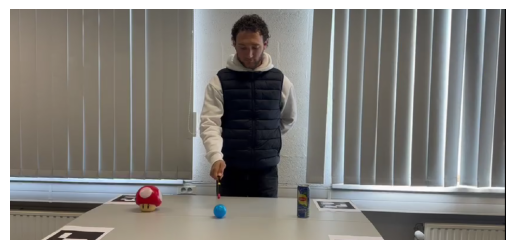

In [ ]:
import cv2 as cv 
import matplotlib.pyplot as plt 
import numpy as np 
from code.ROI import *
from helper import *

# define some path 
in_path  = "data/group_11_fixed.mp4"       
out_path = "output/fixed_group_11_trick2_ball.mp4"
json_path = "data/annotations_group_11.json"

path = dict()

path["in_path"] = "data/group_11_fixed.mp4"
path["out_path"] = "output/fixed_group_11_trick2.mp4"
path["json_path"] = "data/annotations_group_11.json"

load_json(json_path , True , 2)
img = cv.imread("data/oneFramewithWand.png")
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
plt.axis("off")

# Once image read we detect the ball
- now we should define the function func2 to be passed to process defined in utils to apply the trick to the frame 



Hue value of the target color: 120


(np.float64(-0.5), np.float64(1886.5), np.float64(876.5), np.float64(-0.5))

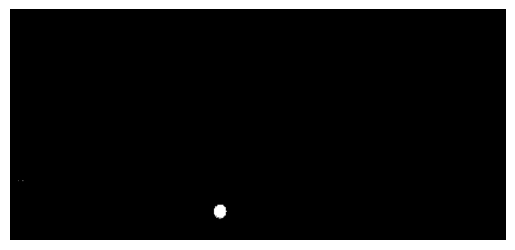

In [18]:
# detect the ball 

RGB = [0,0,255]
lower = [100,100]
upper = [255,255]
mask = detect_color(img,RGB,lower,upper, tuning = 25)
plt.imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
plt.axis("off")

# once the ball detected we could do small erosion & dilatation 

(np.float64(-0.5), np.float64(1886.5), np.float64(876.5), np.float64(-0.5))

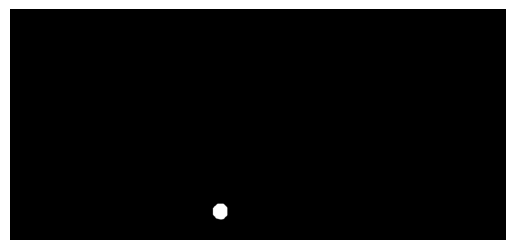

In [4]:
s = 10
SE= cv.getStructuringElement(cv.MORPH_ELLIPSE,(s,s))
eroded_mask = cv.erode(mask,SE)
s = 20
SE= cv.getStructuringElement(cv.MORPH_ELLIPSE,(s,s))
dilated_mask = cv.dilate(eroded_mask,SE)
plt.imshow(cv.cvtColor(dilated_mask, cv.COLOR_BGR2RGB))
plt.axis("off")
# preprocess is important because there still exist tiny white dot that we do not see on the plot 
# but appears if we plot directly with arbitrary big s the dilation of the mask

Hue value of the target color: 120


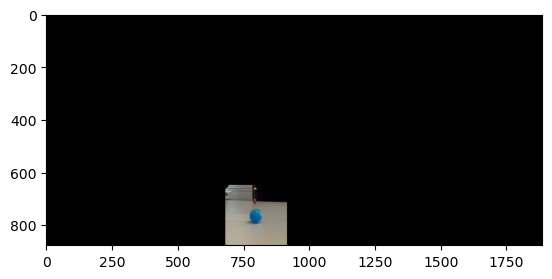

In [5]:
# Then know we generate our ROI around this ball 
RGB = [0,0,255]
out = roi(img , RGB ,lower,upper, s_erod=10 , s_dil=200)
new_image, roi_mask  = out[0] , out[1]

Hue value of the target color: 179
there is  (431,) element in white this is clearly an object 
max in mask is  255
min in mask is  0


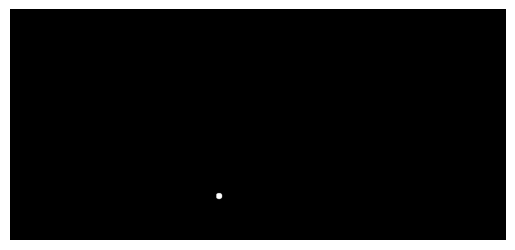

In [6]:
# now we can just work on this tiny area and consider that if the wand access it (so there is red in it )
# then change the color 
RGB = [255,0,10]
lower = [50 , 50]
upper = [255,255]
mask_test= detect_color(new_image,RGB,lower,upper, tuning = 25) # detect red color
#plt.imshow(cv.cvtColor(mask_test , cv.COLOR_BGR2RGB))

# we can see that there is red in the dark , but to avoid to count noise  we do first an erode + dilatation 
# then we count if there is at least (for example) 10 white pixel 
s = 10
SE= cv.getStructuringElement(cv.MORPH_RECT,(s,s))
eroded_mask_test = cv.erode(mask_test,SE)
s = 20
SE= cv.getStructuringElement(cv.MORPH_ELLIPSE,(s,s))
dilated_mask_test= cv.dilate(eroded_mask_test,SE)
plt.imshow(cv.cvtColor(dilated_mask_test , cv.COLOR_BGR2RGB))
plt.axis("off")
print("there is ",np.shape(np.where(dilated_mask_test == 255)[1]) , "element in white this is clearly an object ")
print("max in mask is " , np.max(dilated_mask_test))
print("min in mask is " , np.min(dilated_mask_test))

Hue value of the target color: 120
the color change worked successfully 
(877, 1887, 3)


(np.float64(-0.5), np.float64(1886.5), np.float64(876.5), np.float64(-0.5))

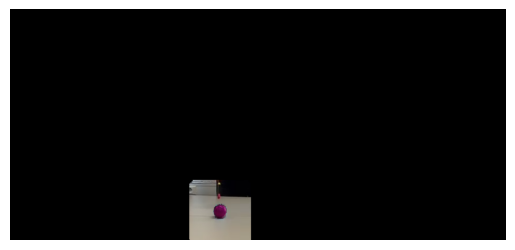

In [7]:
# Then since we detect the red wand we should change the color 
image = new_image
orig_rgb = [0,0,255]
target_rgb = [200,5,6]
img_test = change_color(image, orig_rgb, target_rgb,lower,upper, tuning=25)
print(np.shape(img_test))
plt.imshow(cv.cvtColor(img_test,cv.COLOR_BGR2RGB))
plt.axis("off")

In [8]:
np.shape(img_test)

(877, 1887, 3)

(877, 1887, 3)


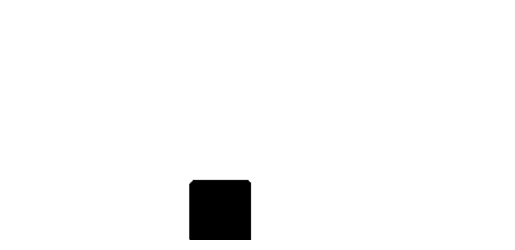

In [9]:
# Invert mask to get where we should take from the original

mask_inv = cv2.bitwise_not(roi_mask)
plt.imshow(cv.cvtColor(mask_inv,cv.COLOR_BGR2RGB))
plt.axis("off")
print(np.shape(img))

(np.float64(-0.5), np.float64(1886.5), np.float64(876.5), np.float64(-0.5))

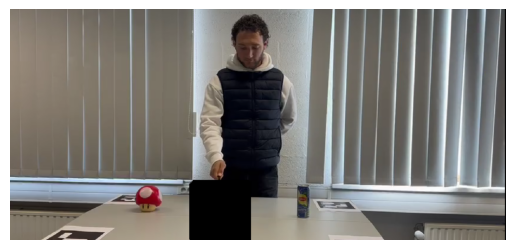

In [10]:
img_not_processed = cv2.bitwise_and(img,img, mask=mask_inv)
plt.imshow(cv.cvtColor(img_not_processed,cv.COLOR_BGR2RGB))
plt.axis("off")

In [11]:
np.shape(img_not_processed) , np.shape(img_test)

((877, 1887, 3), (877, 1887, 3))

(np.float64(-0.5), np.float64(1886.5), np.float64(876.5), np.float64(-0.5))

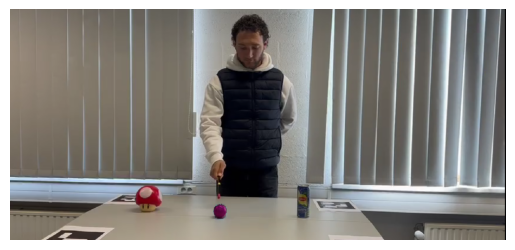

In [12]:
combined = cv2.add(img_test, img_not_processed)
plt.imshow(cv.cvtColor(combined,cv.COLOR_BGR2RGB))
plt.axis("off")

In [13]:
if not np.shape(img_not_processed)== np.shape(img_test):
    print("true")

In [21]:
def change_color_mask(image, orig_rgb, target_rgb, mask):
    """
    Change a specific color in an image to a target color.

    Args:
        image (np.array):  and input image in BGR format 
        orig_rgb (tuple): origin color in RGB format like [255,0,0]
        target_rgb (tuple): target color in RGB format like [0,255,0]
        mask (np.array) :  The mask to be used to change the color
    Returns:
        (np.array): image with the color changed in BGR format
        """
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    orig_hsv = cv2.cvtColor(np.uint8([[orig_rgb]]), cv2.COLOR_RGB2HSV)[0][0]
    target_hsv = cv2.cvtColor(np.uint8([[target_rgb]]), cv2.COLOR_RGB2HSV)[0][0]

    delta_h = (int(target_hsv[0]) - int(orig_hsv[0])) % 180
    if delta_h > 90:
        delta_h -= 180

    delta_s = int(target_hsv[1]) - int(orig_hsv[1])
    delta_v = int(target_hsv[2]) - int(orig_hsv[2])
    
    h, s, v = cv2.split(hsv)
    h = np.mod(h.astype(np.int16) + delta_h, 180).astype(np.uint8)
    s = np.clip(s.astype(np.int16) + delta_s, 0, 255).astype(np.uint8)
    v = np.clip(v.astype(np.int16) + delta_v, 0, 255).astype(np.uint8)

    
    hsv_shifted = cv2.merge([h, s, v])
    bgr_shifted = cv2.cvtColor(hsv_shifted, cv2.COLOR_HSV2BGR)
    
    result = cv2.bitwise_or(
        cv2.bitwise_and(image, image, mask=cv2.bitwise_not(mask)),
        cv2.bitwise_and(bgr_shifted, bgr_shifted, mask=mask)
    )
    print("HELLO FROM NEW COLOR CHANGE !!!!!!!!!")
    print("the color change worked successfully ")
    
    return result

In [ ]:
from code.ROI import * 
from helper import *
import cv2 as cv
data_dict = dict()
data_dict["RGB"] = [0,0,255]  # the color to be detected
data_dict["lower"]=[100,100]  # lower s, lower v to be used to detect the color in hsv format
data_dict["upper"] =[255,255] # upper s, upper v to be used to detect the color in hsv format
data_dict["s_erod"] = 10      # to be used to reduce noise with erosion
data_dict["s_dil"]  = 20     # used to smooth contour of mask after an erosion 
data_dict["threshold"] = 50   # in pixel, used to determine if a color is detected correctly 

def do_trick2_1obj(img ,data_dict ):
    
    RGB = data_dict["RGB"]
    lower = data_dict["lower"]
    upper =data_dict["upper"]
    mask = detect_color(img,RGB,lower,upper, tuning = 25)
    
    s_erod = data_dict["s_erod"]
    SE= cv.getStructuringElement(cv.MORPH_ELLIPSE,(s_erod,s_erod))
    eroded_mask = cv.erode(mask,SE)
    s_dil = data_dict["s_dil"]
    SE= cv.getStructuringElement(cv.MORPH_ELLIPSE,(s_dil,s_dil))
    dilated_mask_object = cv.dilate(eroded_mask,SE)
    
    #RGB = [0,0,255] same as before
    out= roi(img , RGB ,lower,upper, s_erod=10 , s_dil=200)
    new_image, roi_mask  = out[0] , out[1]
    # here since new image is only restricted to the ball ROI
    # we want to detect the red wand 
    # those parameter are tested and work correctly but could be adapted 
    RGB_red = [255,0,10] # red
    lower = [50 , 50]
    upper = [255,255]
    mask_test= detect_color(new_image,RGB_red,lower,upper, tuning = 25) # detect red color
    

    SE= cv.getStructuringElement(cv.MORPH_RECT,(s_erod,s_erod))
    eroded_mask_test = cv.erode(mask_test,SE)

    SE= cv.getStructuringElement(cv.MORPH_ELLIPSE,(s_dil,s_dil))
    
    dilated_mask_test= cv.dilate(eroded_mask_test,SE)
    
    # now we count how much white pixel we have on the new mask 
    n_pixel = np.shape(np.where(dilated_mask_test == 255))[1]
    threshold =data_dict["threshold"]
    result = img
    print("detect pixel = " , n_pixel)
    print("threshold" , threshold)
    if n_pixel < threshold  :
        print("there is NOT enough pixel to consider wand  the object as detected")
        return result  , False
    
    print("there is  enough pixel to consider the wand  as detected to apply the trick 2")

    
    # now we start the changing color process 
    orig_rgb   = RGB
    target_rgb = [200,5,6] # to be changed !!!!!!
    #img_test = change_color(new_image, orig_rgb, target_rgb,lower,upper, tuning=25)
    img_test = change_color_mask(new_image,orig_rgb, target_rgb , dilated_mask_object)
    print("img_test have a shape of ",np.shape(img_test))
    
    mask_inv = cv.bitwise_not(roi_mask)
    img_not_processed = cv.bitwise_and(img,img, mask=mask_inv)
    if not np.shape(img_not_processed)== np.shape(img_test):
        print("There is something wrong with the shape of img_not_processed and img_test")
        return result , False 
    combined = cv2.add(img_test, img_not_processed)
    print(" the combination of the processed and unprocessed part work successfully")
    return combined  , True 

In [ ]:
from code.ROI import * 
from helper import *
from trick2 import *
import cv2 as cv
data_dict = dict()
data_dict["RGB"] = [0,0,255]  # the color to be detected
data_dict["lower"]=[100,100]  # lower s, lower v to be used to detect the color in hsv format
data_dict["upper"] =[255,255] # upper s, upper v to be used to detect the color in hsv format
data_dict["s_erod"] = 10      # to be used to reduce noise with erosion
data_dict["s_dil"]  = 20     # used to smooth contour of mask after an erosion 
data_dict["threshold"] = 50   

Hue value of the target color: 120
Hue value of the target color: 120
Hue value of the target color: 179
there is  enough pixel to consider the wand  as detected to apply the trick 2
HELLO FROM NEW COLOR CHANGE !!!!!!!!!
the color change worked successfully 
img_test have a shape of  (877, 1887, 3)
 the combination of the processed and unprocessed part work successfully


(np.float64(-0.5), np.float64(1886.5), np.float64(876.5), np.float64(-0.5))

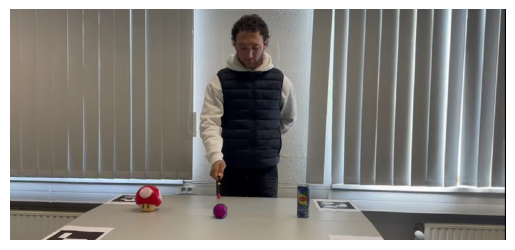

In [6]:
img = cv.imread("data/oneFramewithWand.png")
result,status= do_trick2_1obj(img,data_dict)
plt.imshow(cv.cvtColor(result , cv.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(1056.5), np.float64(600.5), np.float64(-0.5))

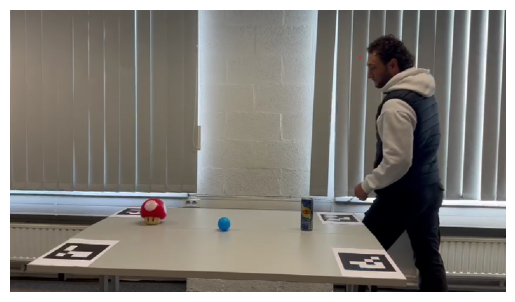

In [88]:
img2 = cv.imread("data/oneFrame.png")
plt.imshow(cv.cvtColor(img2 , cv.COLOR_BGR2RGB))
plt.axis("off")

Hue value of the target color: 120
Hue value of the target color: 120
Hue value of the target color: 179
detect pixel =  0
threshold 50
there is NOT enough pixel to consider wand  the object as detected
False


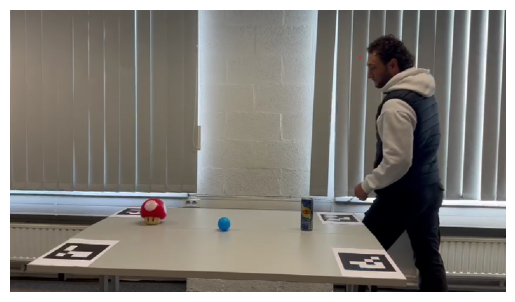

In [91]:
result2,status = do_trick2_1obj(img2,data_dict)
plt.imshow(cv.cvtColor(result2,cv.COLOR_BGR2RGB))
plt.axis("off")
print(status)

In [ ]:
# now that we can detect when to change the color and when to not let's juste process multiple color in a single shot 

from code.ROI import * 
from helper import *
import cv2 as cv
data_dict_list = dict()
#  ###### A LIST ####"the color to be detected
data_dict_list["RGB"] = [[0,0,255] , [255,0,10] ]  # just add color tuple to be detected 
#  ###### A LIST ####" lower s, lower v to be used to detect the color in hsv format
data_dict_list["lower"]=[[100,100] , [50 ,50]]
# ###### A LIST ####"  upper s, upper v to be used to detect the color in hsv format
data_dict_list["upper"] =[[255,255] ,[255,255]]

data_dict_list["s_erod"] = 10      # to be used to reduce noise with erosion
data_dict_list["s_dil"]  = 20     # used to smooth contour of mask after an erosion 
data_dict_list["threshold"] = 50   # in pixel, used to determine if a color is detected correctly 

def do_trick2_nobj(img ,data_dict_list ):
    
    #GET from data_dict_list
    RGBs = data_dict_list["RGB"]
    lowers = data_dict_list["lower"]
    uppers =data_dict_list["upper"]
    s_erod = data_dict_list["s_erod"]
    s_dil = data_dict_list["s_dil"]
    threshold =data_dict_list["threshold"]
    n_colors = len(RGBs)
    
    #SET for  each data_dict
    data_dict = dict()
    data_dict["s_erod"]     =  s_erod    # to be used to reduce noise with erosion  
    data_dict["s_dil"]      =  s_dil    # used to smooth contour of mask after an erosion 
    data_dict["threshold"] =threshold   # in pixel, used to determine if a color is detected correctly 
    if not (len(lowers) == len(uppers) == n_colors) : 
        print("ERROR in do_trick2_nobj")
        print("THE length of RGBs color , Uppers and Lowers hsv should be the same")
        return img
    for n in range(n_colors) :
        
        data_dict["RGB"] = RGBs[n]  # the color to be detected
        data_dict["lower"]=lowers[n] # lower s, lower v to be used to detect the color in hsv format
        data_dict["upper"] =uppers[n] # upper s, upper v to be used to detect the color in hsv format
        
        result,status = do_trick2_1obj(img,data_dict)
        if status ==  True :  #meaning that a color was changed 
            #then we do not need to check the other because the wand is at one place at the time 
            break 
    return result 
    
    

Hue value of the target color: 120
Hue value of the target color: 120
Hue value of the target color: 179
detect pixel =  0
threshold 50
there is NOT enough pixel to consider wand  the object as detected
Hue value of the target color: 179
Hue value of the target color: 179
Hue value of the target color: 179
detect pixel =  5529
threshold 50
there is  enough pixel to consider the wand  as detected to apply the trick 2
HELLO FROM NEW COLOR CHANGE !!!!!!!!!
the color change worked successfully 
img_test have a shape of  (887, 1916, 3)
 the combination of the processed and unprocessed part work successfully
False


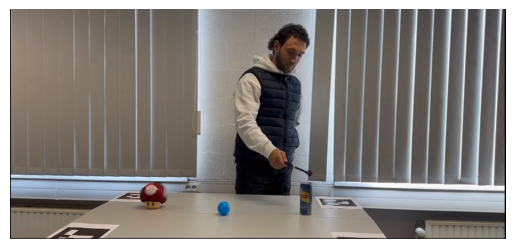

In [114]:
img = cv.imread("data/img5.png")
result = do_trick2_nobj(img,data_dict_list)
plt.imshow(cv.cvtColor(result,cv.COLOR_BGR2RGB))
plt.axis("off")
print(status)